In [1]:
import pandas as pd
data=pd.read_csv("f1_cleaned_data.csv")

In [3]:
data.head()

,raceId,year,round,GrandPrix,Driver,Constructor,QualifyingPosition,FinishingPosition,points,laps,milliseconds
0,18,2008,1,Australian Grand Prix,Hamilton,McLaren,1,1,10.0,58,5690616
1,18,2008,1,Australian Grand Prix,Heidfeld,BMW Sauber,5,2,8.0,58,5696094
2,18,2008,1,Australian Grand Prix,Rosberg,Williams,7,3,6.0,58,5698779
3,18,2008,1,Australian Grand Prix,Alonso,Renault,11,4,5.0,58,5707797
4,18,2008,1,Australian Grand Prix,Kovalainen,McLaren,3,5,4.0,58,5708630


In [4]:
x=data[["year","Driver","Constructor","QualifyingPosition","GrandPrix"]]
y=data["FinishingPosition"]

In [5]:
#catgeorical columns
#GrandPrix	
#Driver
#Constructor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split


In [6]:
features=['GrandPrix',	'Driver'	,'Constructor']
preprocessor=ColumnTransformer(
    [ ('onehot',OneHotEncoder(handle_unknown='ignore'),features)],
    remainder='passthrough')

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#train linear regression model


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [10]:
model=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

In [11]:
model.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['GrandPrix', 'Driver',
                                                   'Constructor'])])),
                ('regressor', LinearRegression())])

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [13]:
y_pred=model.predict(x_test)
mae=mean_absolute_error(y_test,y_pred)
mse= mean_squared_error(y_test,y_pred)
rmse=mse**0.5
print(f"MAE: {mae: .2f}")
print(f"MSE: {mse: .2f}")
print(f"RMSE: {rmse: .2f}")



MAE:  5.32
MSE:  42.22
RMSE:  6.50


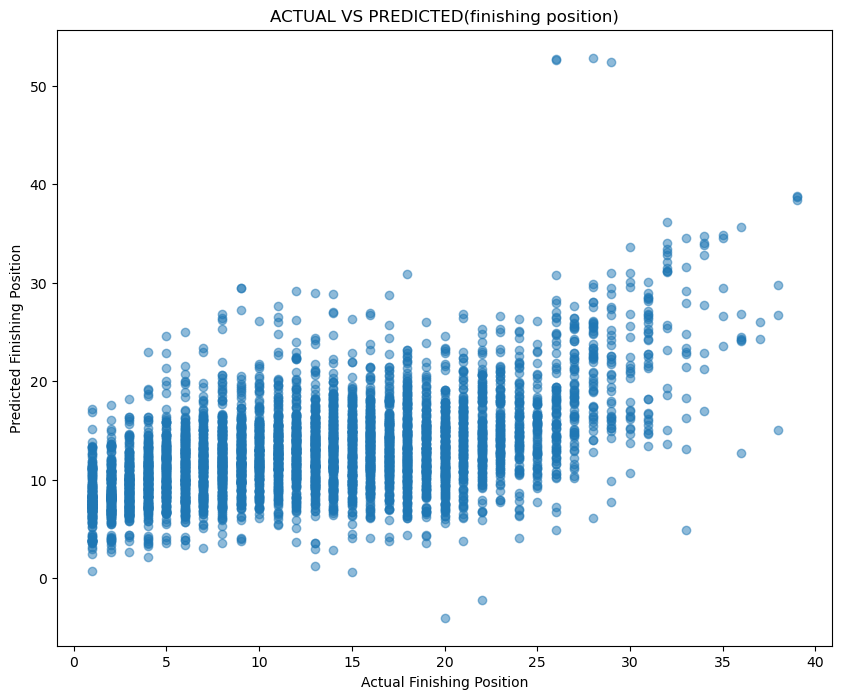

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
plt.scatter(y_test,y_pred,alpha=0.5)
plt.xlabel("Actual Finishing Position")
plt.ylabel("Predicted Finishing Position")
plt.title("ACTUAL VS PREDICTED(finishing position)")
plt.show()


In [15]:
import pickle

with open('f1_model.pkl', 'wb') as file:
    pickle.dump(model, file)
